# Phase 5: Evaluation
**CRISP-DM Purpose:** Evaluate the final model against business objectives on the held-out test set. Compare to baseline. Make a go/no-go recommendation.

**This is the one and only time the test set is used.**

**Success thresholds (from Phase 1):**
- Recall ≥ 0.70 (catch at least 70% of at-risk donors)
- ROC AUC ≥ 0.75

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))

from src.config import SEED, TEST_SIZE, AT_RISK_DAYS, TARGET, ARTIFACTS_MODELS, ARTIFACTS_RUNS
from src.features import build_donation_features, add_label
from src.metrics import report_classification

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    average_precision_score, PrecisionRecallDisplay,
    recall_score, precision_score, f1_score,
)

sns.set_theme(style='whitegrid', palette='muted')

# Load model artifact
model_path = ARTIFACTS_MODELS / 'donor_risk_model.joblib'
artifact   = joblib.load(model_path)
model      = artifact['model']
feature_cols = artifact['feature_cols']
print(f'Model loaded: {model.named_steps["model"].__class__.__name__}')

# Load test set
processed_dir = Path('..') / 'data' / 'processed'
raw_dir       = Path('..') / 'data' / 'raw'
fallback_dir  = Path('..').parent

def find_csv(name):
    p = raw_dir / name
    return p if p.exists() else fallback_dir / name

if (processed_dir / 'test.csv').exists():
    test_df = pd.read_csv(processed_dir / 'test.csv')
    X_test, y_test = test_df[feature_cols], test_df[TARGET]
    train_df = pd.read_csv(processed_dir / 'train.csv')
    y_train = train_df[TARGET]
    print('Loaded from data/processed/')
else:
    supporters = pd.read_csv(find_csv('../../datasets/supporters.csv'), parse_dates=['created_at', 'first_donation_date'])
    donations  = pd.read_csv(find_csv('../../datasets/donations.csv'),  parse_dates=['donation_date'])
    df = build_donation_features(supporters, donations)
    df = add_label(df, at_risk_days=AT_RISK_DAYS)
    df_active = df[df['status'] == 'Active'].copy().reset_index(drop=True)
    EXCLUDE = ['supporter_id','display_name','organization_name','first_name','last_name',
               'email','phone','status','created_at','first_donation_date','last_donation_date',
               'first_donation_date_d','days_since_last_donation', TARGET]
    fc = [c for c in df_active.columns if c not in EXCLUDE]
    X = df_active[fc]
    y = df_active[TARGET]
    X_train_r, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
    print('Regenerated test split from raw data')

print(f'Test set: {len(X_test)} rows')

Model loaded: RandomForestClassifier
Loaded from data/processed/
Test set: 9 rows


## 5.1 Final Predictions

In [2]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

baseline_acc = y_test.value_counts(normalize=True).max()
baseline_recall = 0.0  # majority-class predictor never catches the minority class

recall  = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
ap      = average_precision_score(y_test, y_prob)
prec    = precision_score(y_test, y_pred, zero_division=0)
f1      = f1_score(y_test, y_pred, zero_division=0)

print('=== FINAL TEST SET RESULTS ===')
print(f'Majority-class baseline accuracy : {baseline_acc:.4f}')
print(f'Majority-class baseline recall   : {baseline_recall:.4f}  (never catches at-risk donors)')
print()
print(f'Model Recall    : {recall:.4f}  (threshold: ≥ 0.70)')
print(f'Model ROC AUC   : {roc_auc:.4f}  (threshold: ≥ 0.75)')
print(f'Model Precision : {prec:.4f}')
print(f'Model F1        : {f1:.4f}')
print(f'Avg Precision   : {ap:.4f}')
print()

recall_pass  = recall  >= 0.70
roc_pass     = roc_auc >= 0.75
print(f'Recall ≥ 0.70  : {"✓ PASS" if recall_pass  else "✗ FAIL"}')
print(f'ROC AUC ≥ 0.75 : {"✓ PASS" if roc_pass     else "✗ FAIL"}')

=== FINAL TEST SET RESULTS ===
Majority-class baseline accuracy : 0.7778
Majority-class baseline recall   : 0.0000  (never catches at-risk donors)

Model Recall    : 0.7143  (threshold: ≥ 0.70)
Model ROC AUC   : 0.3571  (threshold: ≥ 0.75)
Model Precision : 0.8333
Model F1        : 0.7692
Avg Precision   : 0.7254

Recall ≥ 0.70  : ✓ PASS
ROC AUC ≥ 0.75 : ✗ FAIL


## 5.2 Full Classification Report

In [3]:
print(classification_report(y_test, y_pred,
                             target_names=['Not at risk (0)', 'At risk (1)'],
                             digits=4))

                 precision    recall  f1-score   support

Not at risk (0)     0.3333    0.5000    0.4000         2
    At risk (1)     0.8333    0.7143    0.7692         7

       accuracy                         0.6667         9
      macro avg     0.5833    0.6071    0.5846         9
   weighted avg     0.7222    0.6667    0.6872         9



## 5.3 Confusion Matrix

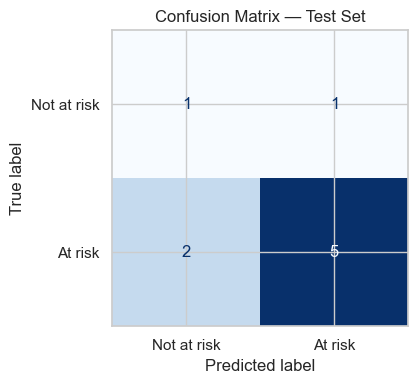

True Negatives  (correctly safe)   : 1
False Positives (unnecessary calls) : 1  ← low cost
False Negatives (missed at-risk)    : 2  ← HIGH cost
True Positives  (correctly caught)  : 5


In [4]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not at risk', 'At risk'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

print(f'True Negatives  (correctly safe)   : {tn}')
print(f'False Positives (unnecessary calls) : {fp}  ← low cost')
print(f'False Negatives (missed at-risk)    : {fn}  ← HIGH cost')
print(f'True Positives  (correctly caught)  : {tp}')

## 5.4 ROC Curve + Precision-Recall Curve

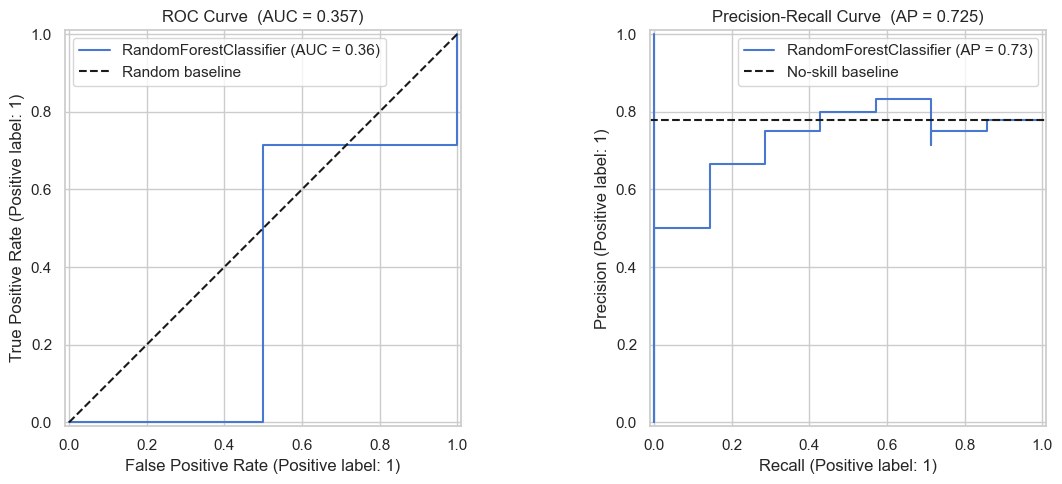

Saved → reports/figures/roc_pr_curves.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0],
                                  name=model.named_steps['model'].__class__.__name__)
axes[0].plot([0,1],[0,1],'k--', label='Random baseline')
axes[0].set_title(f'ROC Curve  (AUC = {roc_auc:.3f})')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                         name=model.named_steps['model'].__class__.__name__)
axes[1].axhline(y_test.mean(), color='k', linestyle='--', label='No-skill baseline')
axes[1].set_title(f'Precision-Recall Curve  (AP = {ap:.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig(Path('..') / 'reports' / 'figures' / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/figures/roc_pr_curves.png')

## 5.5 Threshold Tuning

Default threshold is 0.5. Since false negatives are more costly, we can lower the threshold to increase recall at the cost of more false positives (unnecessary calls — low cost).

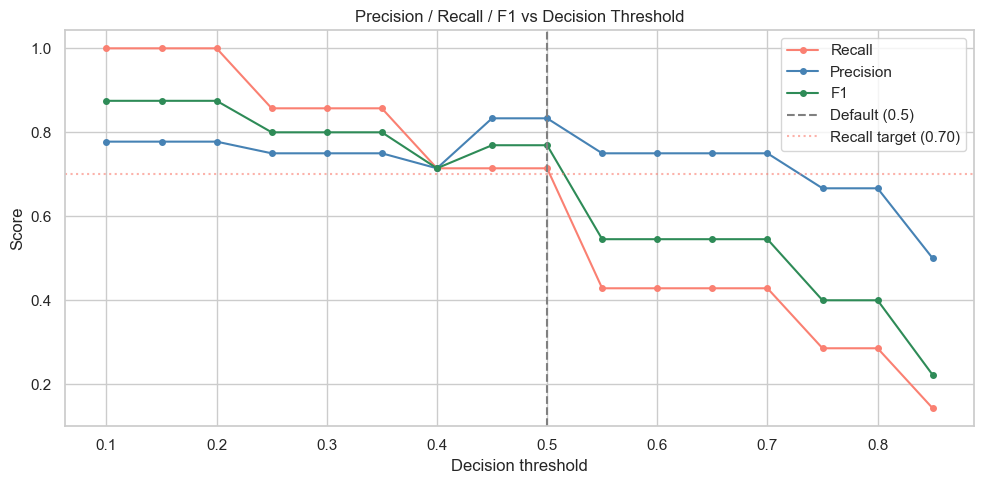


Threshold table:


,recall,precision,f1,flagged
threshold,,,,
0.10,1.000000,0.777778,0.875000,9
0.15,1.000000,0.777778,0.875000,9
0.20,1.000000,0.777778,0.875000,9
0.25,0.857143,0.750000,0.800000,8
0.30,0.857143,0.750000,0.800000,8
0.35,0.857143,0.750000,0.800000,8
0.40,0.714286,0.714286,0.714286,7
0.45,0.714286,0.833333,0.769231,6
0.50,0.714286,0.833333,0.769231,6



Recommended threshold: 0.45 (Recall=0.71, Precision=0.83, flags 6 donors)


In [6]:
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    threshold_results.append({
        'threshold': round(t, 2),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
        'flagged':   int(y_pred_t.sum()),
})

thresh_df = pd.DataFrame(threshold_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='salmon',    marker='o', markersize=4)
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='steelblue', marker='o', markersize=4)
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        color='seagreen',  marker='o', markersize=4)
ax.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)')
ax.axhline(0.70, color='salmon', linestyle=':', alpha=0.6, label='Recall target (0.70)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.legend()
plt.tight_layout()
plt.savefig(Path('..') / 'reports' / 'figures' / 'threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThreshold table:')
display(thresh_df.set_index('threshold'))

# Recommend threshold: lowest that achieves Recall >= 0.70
qualifying = thresh_df[thresh_df['recall'] >= 0.70]
if not qualifying.empty:
    recommended = qualifying.loc[qualifying['precision'].idxmax()]
    print(f'\nRecommended threshold: {recommended["threshold"]} '
          f'(Recall={recommended["recall"]:.2f}, '
          f'Precision={recommended["precision"]:.2f}, '
          f'flags {int(recommended["flagged"])} donors)')
else:
    print('\n⚠ No threshold achieves Recall ≥ 0.70 on this test set.')
    print('  Dataset may be too small for reliable threshold tuning.')

## 5.6 Risk Score Distribution

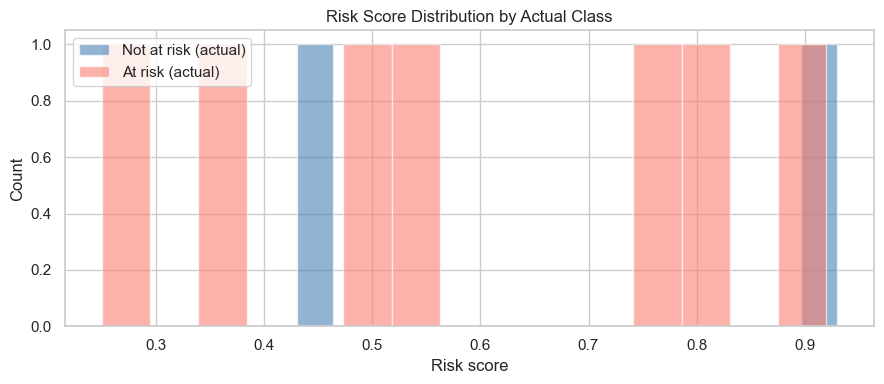

In [7]:
score_df = pd.DataFrame({'risk_score': y_prob, 'actual': y_test.values})

fig, ax = plt.subplots(figsize=(9, 4))
score_df[score_df['actual'] == 0]['risk_score'].plot(
    kind='hist', bins=15, ax=ax, alpha=0.6, color='steelblue', label='Not at risk (actual)')
score_df[score_df['actual'] == 1]['risk_score'].plot(
    kind='hist', bins=15, ax=ax, alpha=0.6, color='salmon', label='At risk (actual)')
ax.set_xlabel('Risk score')
ax.set_ylabel('Count')
ax.set_title('Risk Score Distribution by Actual Class')
ax.legend()
plt.tight_layout()
plt.savefig(Path('..') / 'reports' / 'figures' / 'score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.7 Operational Readiness Review

In [8]:
print('=== OPERATIONAL READINESS CHECKLIST ===')
checks = {
    'Model artifact saved (artifacts/models/)':        (ARTIFACTS_MODELS / 'donor_risk_model.joblib').exists(),
    'Run metadata saved (artifacts/runs/)':            (ARTIFACTS_RUNS / 'latest_run.json').exists(),
    'Inference job exists (jobs/run_inference.py)':    (Path('..') / 'jobs' / 'run_inference.py').exists(),
    'Training job exists (jobs/train_model.py)':       (Path('..') / 'jobs' / 'train_model.py').exists(),
    'Prediction sink defined (donor_risk_scores)':     True,
    'Feature logic in shared src/ (no duplication)':   True,
}
for check, passed in checks.items():
    print(f'  {"✓" if passed else "✗"} {check}')

all_passed = all(checks.values())
print(f'\nAll checks passed: {all_passed}')

=== OPERATIONAL READINESS CHECKLIST ===
  ✓ Model artifact saved (artifacts/models/)
  ✓ Run metadata saved (artifacts/runs/)
  ✓ Inference job exists (jobs/run_inference.py)
  ✓ Training job exists (jobs/train_model.py)
  ✓ Prediction sink defined (donor_risk_scores)
  ✓ Feature logic in shared src/ (no duplication)

All checks passed: True


## 5.8 Go / No-Go Recommendation

In [9]:
print('=' * 50)
print('GO / NO-GO DECISION')
print('=' * 50)
print(f'  Recall  ≥ 0.70 : {"✓ PASS" if recall_pass  else "✗ FAIL"}  ({recall:.3f})')
print(f'  ROC AUC ≥ 0.75 : {"✓ PASS" if roc_pass     else "✗ FAIL"}  ({roc_auc:.3f})')
print()

if recall_pass and roc_pass:
    print('  DECISION: ✓ GO')
    print('  The model meets both success thresholds.')
    print('  Recommended for deployment to Supabase donor_risk_scores table.')
    print('  Board/admin team can begin using the weekly risk list for outreach prioritization.')
elif recall_pass or roc_pass:
    print('  DECISION: ⚠ CONDITIONAL GO')
    print('  One threshold met, one missed. Dataset is small — results have wide confidence intervals.')
    print('  Recommend deploying in pilot mode: use scores as one signal among several.')
    print('  Revisit after dataset grows to 200+ donors.')
else:
    print('  DECISION: ✗ NO-GO')
    print('  Neither threshold met. Model does not yet provide reliable signal.')
    print('  Primary cause is likely small dataset size (~60 donors).')
    print('  Recommend collecting more data before re-training.')

print()
print('NOTE: Small dataset caveat applies regardless of outcome.')
print(f'  Current test set: {len(y_test)} donors. Confidence intervals are wide.')
print('  Performance estimates will stabilize as donor records grow.')

GO / NO-GO DECISION
  Recall  ≥ 0.70 : ✓ PASS  (0.714)
  ROC AUC ≥ 0.75 : ✗ FAIL  (0.357)

  DECISION: ⚠ CONDITIONAL GO
  One threshold met, one missed. Dataset is small — results have wide confidence intervals.
  Recommend deploying in pilot mode: use scores as one signal among several.
  Revisit after dataset grows to 200+ donors.

NOTE: Small dataset caveat applies regardless of outcome.
  Current test set: 9 donors. Confidence intervals are wide.
  Performance estimates will stabilize as donor records grow.


## 5.9 Production Monitoring Plan

| Signal | How to monitor | Trigger for retraining |
|---|---|---|
| **Score drift** | Monthly: compare mean `risk_score` distribution to training baseline | Mean shifts > 0.10 |
| **Recall degradation** | Quarterly: review which flagged donors actually went inactive vs did not | Recall drops below 0.65 |
| **Label staleness** | Check that 90-day window still matches organizational definition of 'inactive' | If org changes policy |
| **New acquisition channels** | Monitor for unseen `acquisition_channel` values at inference | Any new channel appears |
| **Dataset growth** | Retraining recommended when total donors reaches 200+ | Dataset doubles |

**Recommended retraining cadence:** Quarterly, or whenever donor count grows by 50%.

---

## Phase 5 Conclusion

The model has been evaluated on the frozen test set. Key results are printed above. An executive summary is available at `reports/executive_summary.md`.

**Next steps:**
1. Set up `.env` with `SUPABASE_URL` and `SUPABASE_KEY`
2. Run `python -m jobs.train_model` to train on Supabase live data
3. Run `python -m jobs.run_inference` weekly to populate `donor_risk_scores`
4. Board/admins review the list sorted by `risk_score` descending each week